# Week 2: Practical fundamentals of Healthcare Predictive Analysis

**Objective:** To understand and implement a basic predictive model for a healthcare problem. We will predict whether a patient has diabetes based on certain diagnostic measurements.

**Audience:** This notebook is designed for participants with a non-programming background.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Loading the Dataset

We will use the **Pima Indians Diabetes Database**. This dataset is from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective is to predict based on diagnostic measurements whether a patient has diabetes.

The dataset has the following columns:
- **Pregnancies:** Number of times pregnant
- **Glucose:** Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- **BloodPressure:** Diastolic blood pressure (mm Hg)
- **SkinThickness:** Triceps skin fold thickness (mm)
- **Insulin:** 2-Hour serum insulin (mu U/ml)
- **BMI:** Body mass index (weight in kg/(height in m)^2)
- **DiabetesPedigreeFunction:** A function that scores likelihood of diabetes based on family history
- **Age:** Age in years
- **Outcome:** The target variable. 1 if the patient has diabetes, 0 otherwise.

In [18]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(url, names=columns)

# Display the first 5 rows of the dataframe
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Number of data points

In [19]:
print(f"Number of rows in the dataset: {len(df)}")

Number of rows in the dataset: 768


## 2. Exploratory Data Analysis (EDA)

Before building a model, it's crucial to explore and understand the data. This helps in identifying patterns, anomalies, and guiding our modeling choices.

In [20]:
# Get a summary of the dataframe
print("Dataframe Information:")
df.info()

# Get descriptive statistics
print("\nDescriptive Statistics:")
df.describe()

Dataframe Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Descriptive Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.1. Handling Missing Values (Real word data is messy, it needs to be cleaned first)

From `df.describe()`, we can see that for columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`, the minimum value is 0. It's biologically impossible to have a value of 0 for these measurements. This indicates that 0 was likely used to represent missing data.

Ignoring missing data can lead to a poorly performing model. A common strategy is to replace these 'missing' zeros with a more appropriate value, like the mean or median of the column.

In [21]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace 0s with NaN (Not a Number), which is easier to work with
df[columns_with_zeros] = df[columns_with_zeros].replace(0, np.nan)

# Now, let's see how many missing values we have in each column
print("Missing values before imputation:")
print(df.isnull().sum())

# Replace NaN values with the mean of each column
df.fillna(df.mean(), inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())

print("\nDescriptive statistics after handling zeros:")
df.describe()

Missing values before imputation:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Descriptive statistics after handling zeros:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.2. Data Visualization

Visualizations help us understand the data's story intuitively.

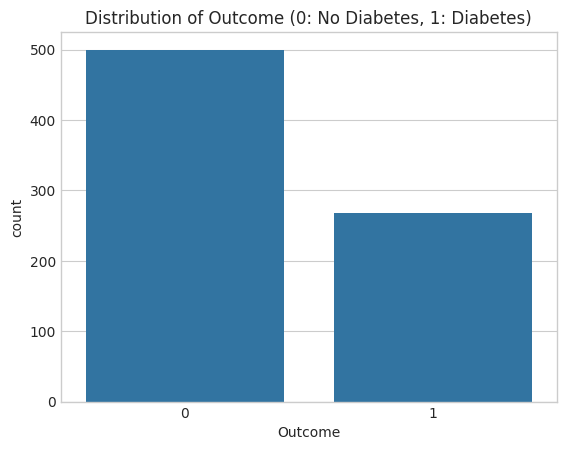

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [22]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Outcome (0: No Diabetes, 1: Diabetes)')
plt.show()

print(df['Outcome'].value_counts(normalize=True))

#### Feature Distributions
Let's look at how the values for each feature are distributed using histograms.

**How to read these plots:**
- **X-axis:** Represents the range of values for a specific medical measurement (e.g., Age in years, Glucose level).
- **Y-axis:** Represents the frequency or the number of patients that fall into that specific range (also called a 'bin').

**What to look for:**
- **Shape:** Is the data bell-shaped (normal) or skewed to one side? For example, 'Age' is typically skewed to the right since there are usually fewer older patients.
- **Outliers:** Are there isolated bars far away from the main group? This could indicate unusual patients or data entry errors.

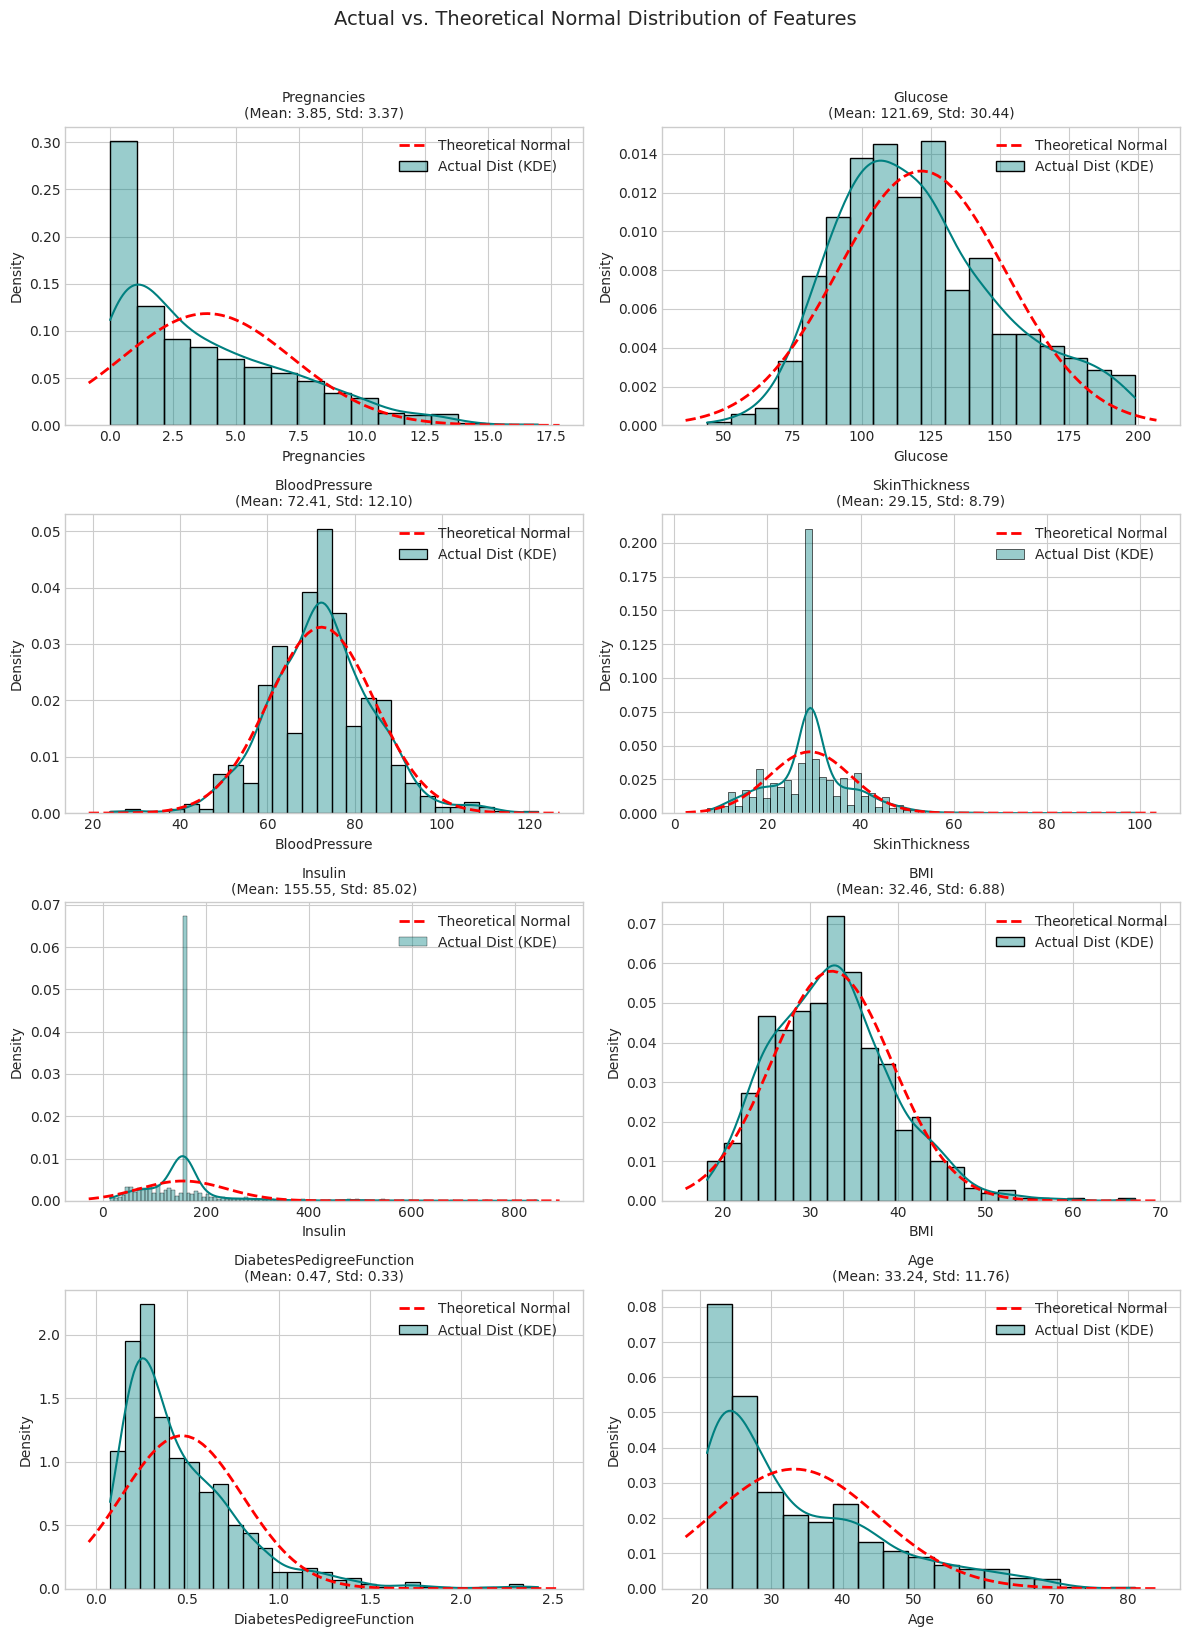

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

def plot_feature_distributions_with_normal(df, cols_float, fig_size):
    """
    Plots the actual distribution of numerical features (Histogram + KDE) 
    against a theoretical normal distribution based on the feature's mean and std.
    """
    n_features = len(cols_float)
    n_rows = (n_features + 1) // 2  # Integer division for ceiling    
    
    fig, axes = plt.subplots(nrows=n_rows, ncols=2, figsize=fig_size, dpi=100)    
    fig.suptitle('Actual vs. Theoretical Normal Distribution of Features', fontsize=14, y=1.02)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # Flatten the axes array to easily iterate through it
    axes = axes.flatten() if n_features > 1 else [axes]
    
    for i, col_name in enumerate(cols_float):
        ax = axes[i]
        
        # Drop missing values to accurately calculate mean and std
        feature_data = df[col_name].dropna()
        
        # 1. Plot the actual distribution
        # stat="density" is crucial here so it scales with the normal PDF
        sns.histplot(
            feature_data, 
            kde=True, 
            stat="density", 
            fill=True, 
            color="teal", 
            alpha=0.4, 
            label="Actual Dist (KDE)", 
            ax=ax
        )
        
        # 2. Calculate actual mean and standard deviation
        mean, std = feature_data.mean(), feature_data.std()
        
        # 3. Create the theoretical normal distribution curve
        # Get the min and max limits of the current X-axis to span our curve properly
        x_min, x_max = ax.get_xlim()
        x_values = np.linspace(x_min, x_max, 100)
        y_values = norm.pdf(x_values, mean, std)
        
        # Plot the normal curve
        ax.plot(
            x_values, 
            y_values, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label="Theoretical Normal"
        )
        
        # Formatting
        ax.set_title(f"{col_name}\n(Mean: {mean:.2f}, Std: {std:.2f})", fontsize=10)
        ax.set_ylabel("Density")
        ax.set_xlabel(col_name)                
        ax.legend()
        
    # Remove any extra subplots if the number of features is odd
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    fig.tight_layout()
    plt.show()   

# --- Execute the function ---
# Replace 'df' with the name of your entire dataset dataframe
# Replace 'cols_float' with your actual list of numerical columns
cols_float = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

plot_feature_distributions_with_normal(df, cols_float, fig_size=(12, 4 * ((len(cols_float) + 1) // 2)))


## Correlation Matrix

A correlation matrix shows the relationship between different variables. A value close to 1 means a strong positive correlation, while a value close to -1 means a strong negative correlation. A value near 0 indicates no correlation.

This helps us see which features are related to the outcome and to each other.

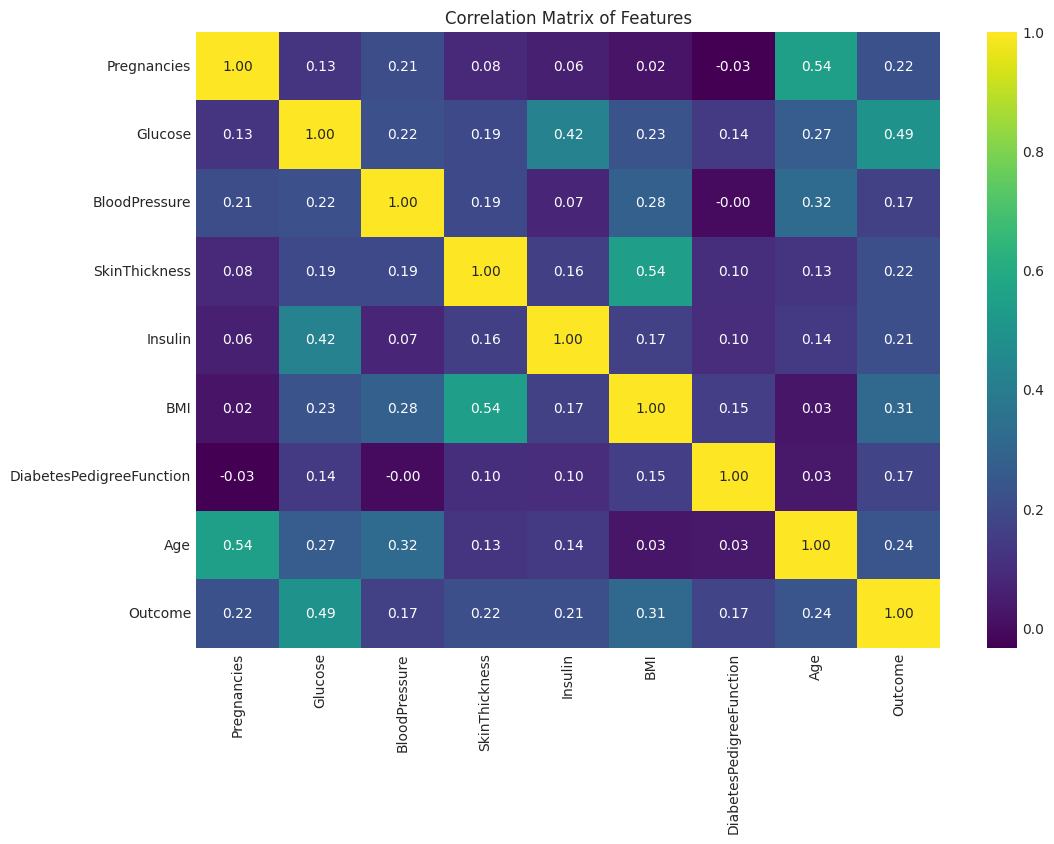

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## 📊 Understanding Normal Distribution and Outliers

### 🧠 Intuition

In healthcare data, most patients fall into a "normal" range, while a few have extreme values.

For example:
- Most patients have BMI between 20–35
- A few may have very high or very low BMI

This pattern often forms a **Normal Distribution (Bell Curve)**.

Most of the natural data distributions we see around us follow a normal distribution pattern. Nature prefers balance, extremes are rare.

Example: Human height, weight, body temperature, errors in measurement
But not every distribution is normal. E.g. Income (skewed), Disease spread (skewed)


### 📈 What is a Normal Distribution?

A distribution where:
- Most values are around the mean
- Symmetrical spread on both sides

Mathematically:

$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}$

Where:
- μ = mean
- σ = standard deviation


### 🤖 Why does this matter for ML?

Some models (like Logistic Regression) work better when features are normally distributed because:
- They assume smooth relationships
- Extreme values can distort learning

Linear models (like logistic or linear regression) use gradient descent alogorithm for optimization and it works best when all features are on a similar scale and spread symmetrically (like a normal distribution).

When data is skewed or unscaled: The mathematical "landscape" the algorithm navigates becomes an elongated, jagged valley. The optimizer will zig-zag wildly, taking a very long time to find the bottom (the best weights), or it might get stuck entirely.

When data is normal: The landscape becomes a smooth, symmetrical bowl. The optimizer walks straight down to the most accurate weights with high efficiency and stability.

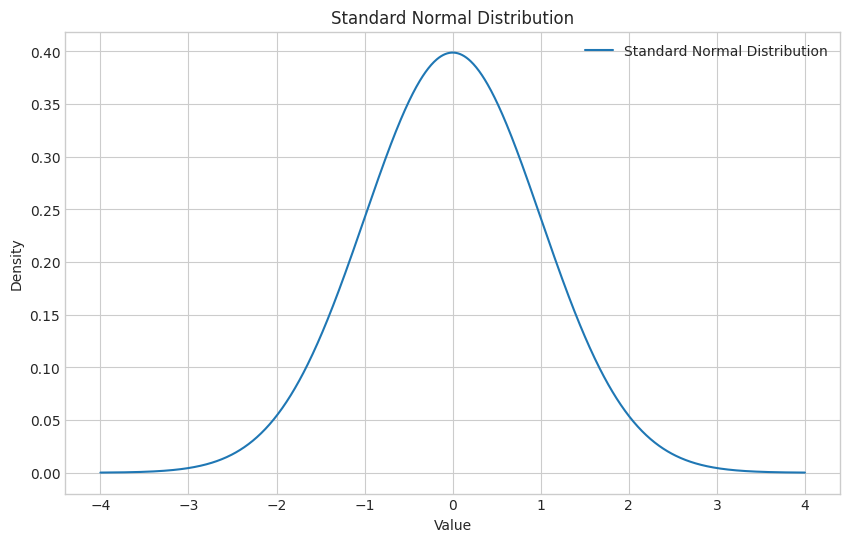

In [25]:
# Display a sample normal distribution curve
from scipy.stats import norm
plt.figure(figsize=(10, 6))
x = np.linspace(-4, 4, 1000)
plt.plot(x, norm.pdf(x), label='Standard Normal Distribution')
plt.title('Standard Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## 🔄 Fixing Skewed Data

We can transform features to make them more normal:

- Log Transform → reduces large values
- Square Root → softens skew
- Standardization → rescales data


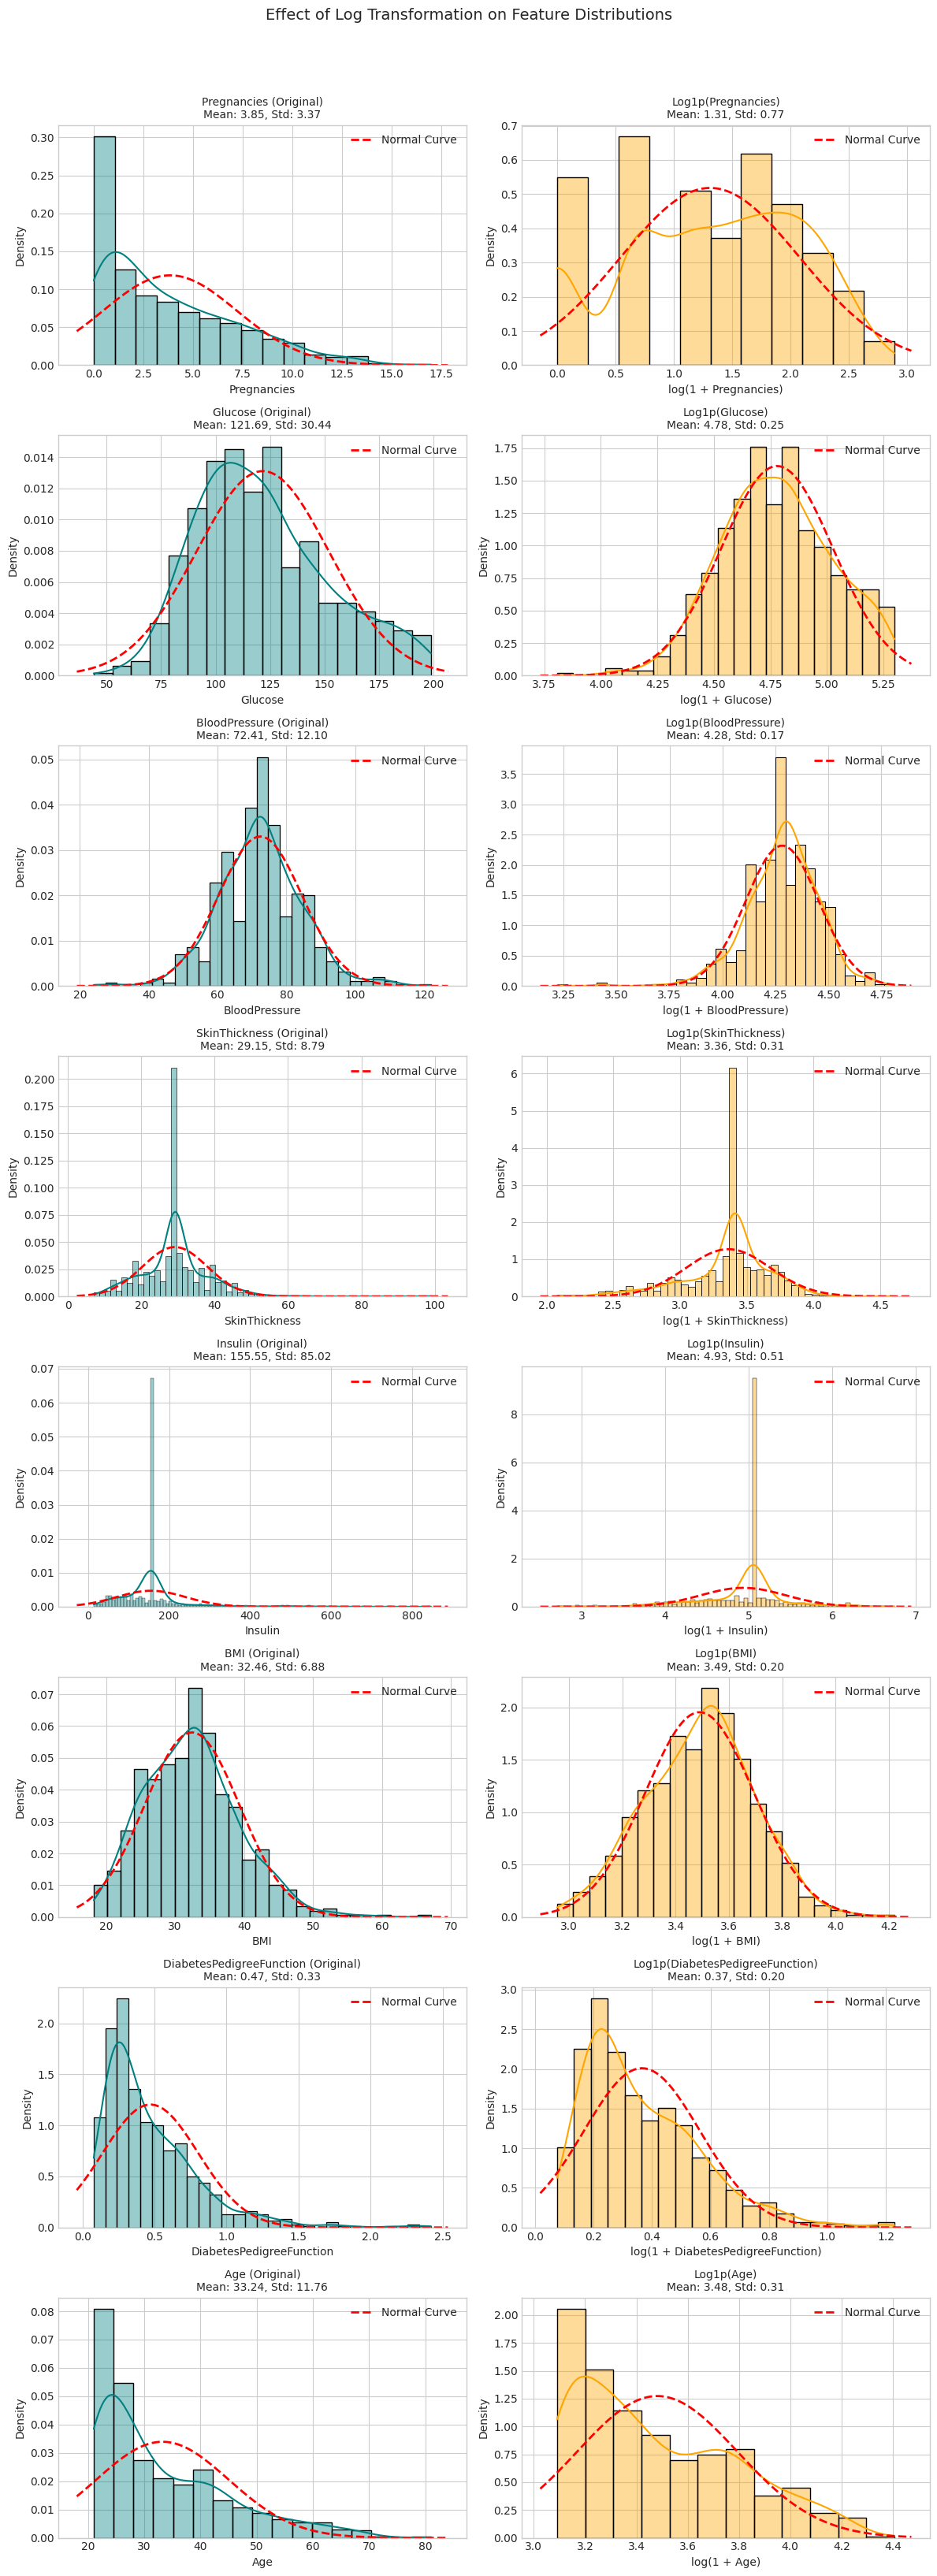

In [26]:
# I want to fix the distribution of the features to be more normal. I will use log transformation for that. I'll show how each input
# feature's distribution changes after log transformation. I'll also show how the normal distribution curve fits better after log transformation.
# For this I'll plot the distribution of each feature before and after log transformation, along with the normal distribution curve for both cases. 
# This will help us visualize the effect of log transformation on the distribution of the features.

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

def plot_log_transform_effect(df, cols_float, fig_size):
    """
    Plots the original distribution vs. the log-transformed distribution
    for a list of numerical features, overlaid with theoretical normal curves.
    """
    n_features = len(cols_float)
    
    # Create a grid with n_features rows and 2 columns
    fig, axes = plt.subplots(nrows=n_features, ncols=2, figsize=fig_size, dpi=100)    
    fig.suptitle('Effect of Log Transformation on Feature Distributions', fontsize=14, y=1.02)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # Ensure axes is always a 2D array even if there's only 1 feature
    axes = np.atleast_2d(axes)
    
    for i, col_name in enumerate(cols_float):
        # Drop missing values
        orig_data = df[col_name].dropna()
        
        # Apply log(1+x) transformation to safely handle 0s
        # (If your data has negative values, consider a different scaler or shift the data first)
        log_data = np.log1p(orig_data)
        
        # ---------------------------------------------------
        # 1. Left Subplot: Original Data Distribution
        # ---------------------------------------------------
        ax_orig = axes[i, 0]
        sns.histplot(orig_data, kde=True, stat="density", fill=True, color="teal", alpha=0.4, ax=ax_orig)
        
        mean_orig, std_orig = orig_data.mean(), orig_data.std()
        x_min, x_max = ax_orig.get_xlim()
        x_vals = np.linspace(x_min, x_max, 100)
        y_vals = norm.pdf(x_vals, mean_orig, std_orig)
        
        ax_orig.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2, label="Normal Curve")
        ax_orig.set_title(f"{col_name} (Original)\nMean: {mean_orig:.2f}, Std: {std_orig:.2f}", fontsize=10)
        ax_orig.set_ylabel("Density")
        ax_orig.set_xlabel(col_name)                
        ax_orig.legend()

        # ---------------------------------------------------
        # 2. Right Subplot: Log-Transformed Data Distribution
        # ---------------------------------------------------
        ax_log = axes[i, 1]
        sns.histplot(log_data, kde=True, stat="density", fill=True, color="orange", alpha=0.4, ax=ax_log)
        
        mean_log, std_log = log_data.mean(), log_data.std()
        x_min_log, x_max_log = ax_log.get_xlim()
        x_vals_log = np.linspace(x_min_log, x_max_log, 100)
        y_vals_log = norm.pdf(x_vals_log, mean_log, std_log)
        
        ax_log.plot(x_vals_log, y_vals_log, color='red', linestyle='--', linewidth=2, label="Normal Curve")
        ax_log.set_title(f"Log1p({col_name})\nMean: {mean_log:.2f}, Std: {std_log:.2f}", fontsize=10)
        ax_log.set_ylabel("Density")
        ax_log.set_xlabel(f"log(1 + {col_name})")                
        ax_log.legend()
        
    fig.tight_layout()
    plt.show()   

# --- Execute the function ---

plot_log_transform_effect(df, cols_float, fig_size=(12, 4 * len(cols_float)))

---
## 2.3. Identifying and Handling Outliers (The 'Odd Ones Out')

**What is an outlier?** An outlier is a data point that differs significantly from other observations. Imagine calculating the average wealth in a room of 10 people, and a billionaire walks in. The average shoots up, but it no longer represents the 'typical' person in that room. That billionaire is an outlier.

**Why do they matter?** Machine learning models learn from patterns. Extreme outliers can "pull" the model's boundary in the wrong direction, making it less accurate for the vast majority of normal patients.

**How do we spot them?** A **Boxplot** is a fantastic visual tool for this. The main 'box' shows where most of the data lies, and the 'whiskers' extend to the normal expected range. Anything beyond the whiskers is plotted as an individual dot—an outlier!

### 2.4. Calculating the Whisker Boundaries
To calculate the whiskers, you first need three specific values:
* **$Q1$ (First Quartile):** The $25^{th}$ percentile (the bottom of the box).
* **$Q3$ (Third Quartile):** The $75^{th}$ percentile (the top of the box).
* **IQR (Interquartile Range):** The height of the box, calculated as $IQR = Q3 - Q1$.

The standard method for determining the reach of the whiskers is the **Tukey Boxplot** method. It uses a "step" of $1.5$ times the $IQR$ to find the upper and lower limits.

#### The Mathematical "Fences"
First, we calculate the theoretical limits, often called the **inner fences**:
* **Lower Fence** $= Q1 - 1.5 \times IQR$
* **Upper Fence** $= Q3 + 1.5 \times IQR$

If your data follows a Normal Distribution, the whiskers (at $1.5 \times IQR$) will encompass approximately $99.3\%$ of your data.

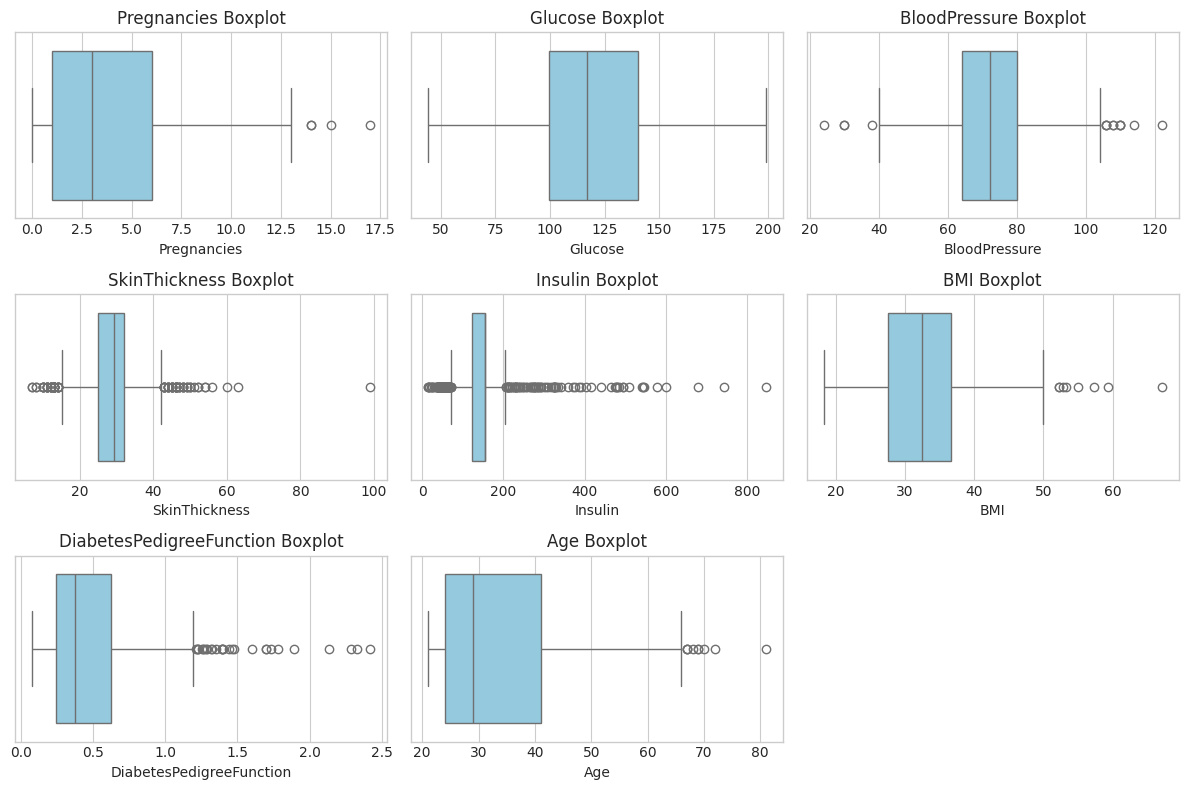

In [27]:
# I want to plot the boxplot of each of the input features to see if there are any outliers in the data. 
# I will use seaborn's boxplot function for this. I will create a boxplot for each of the numerical features in the dataset. 
# Plot three boxplots per row, increase the width of each plot and reduce the height of each plot to make them more compact.    

plt.figure(figsize=(12, 4 * ((len(cols_float) + 1) // 4)))
for i, col_name in enumerate(cols_float):
    plt.subplot((len(cols_float) + 1) // 3, 3, i + 1)
    sns.boxplot(x=df[col_name], color='skyblue')
    plt.title(f"{col_name} Boxplot")
plt.tight_layout()
plt.show()

Notice the dots extending far to the right? Those represent patients with unusually high BMI.

**How do we handle them?**
1.  **Drop them:** If we know it's a data entry error (e.g., a patient's age is typed as 250 years), we simply remove that row.
2.  **Cap them (Winsorization):** We can set a maximum limit. For instance, any BMI above 55 is just capped and treated as 55 so it doesn't skew the math too heavily.
3.  **Leave them alone:** In healthcare, extreme values are often real and clinically significant. Removing them might mean ignoring the sickest patients! Always consult a medical expert before altering clinical data.

*For this introductory model, we will leave the outliers as they are, but it's important to understand their impact!*

---

### Effect of outliers on model's predictions:

"Imagine we are building a machine learning model to predict how many days a patient will stay in the hospital after a routine appendectomy.

We look at 100 patients. 99 of those patients recover normally and go home in 2 to 3 days. However, 1 patient (our extreme outlier) develops a very rare complication and ends up staying in the hospital for 90 days.

Machine learning models are essentially people-pleasers; they try to minimize their overall error for the entire group. If the model predicts everyone will stay 2 days, it's going to be off by a massive 88 days for that one outlier. To avoid being mathematically 'penalized' by that huge gap, the model gets pulled toward the outlier and might predict that the average patient will stay 7 or 8 days.

Because it tried so hard to account for that one rare 90-day case, the model is now giving terrible, inaccurate predictions for the 99 normal patients who only need to stay 2 days."

### ⚠️ The Problem with Outliers

Machine learning models learn from patterns.

Extreme outliers can **pull the model in the wrong direction**, making it less accurate for most patients.

Think of it like:
> Making healthcare decisions based on one unusual patient instead of the majority.

---

## 3. Data Preparation for Modeling

Now we prepare the data for our machine learning model.

In [28]:
# 'X' contains our features (the patient's data)
X = df.drop("Outcome", axis=1)

# 'y' contains our target (whether they have diabetes or not)
y = df["Outcome"]

### 3.1. Splitting Data into Training and Testing Sets

We split our dataset into two parts:
1.  **Training set:** The model learns from this data (e.g., 80% of the data).
2.  **Testing set:** We use this data to evaluate how well our model performs on unseen data (e.g., 20% of the data).

This is crucial to ensure our model can generalize to new, real-world patients.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# We use 'stratify=y' to ensure that the proportion of outcomes (0 and 1) is the same in both the train and test sets.

### 3.2. Feature Scaling

Our features have different scales (e.g., 'Age' vs. 'Insulin'). Some machine learning models can be sensitive to this. Feature scaling standardizes the range of the features.

**Important:** We fit the scaler *only* on the training data to prevent information from the test set from 'leaking' into our training process. We then use that same fitted scaler to transform both the training and testing data.

### 🔹 A. Normalization (Min-Max Scaling)

#### Formula:

$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$

👉 Output range: **0 to 1**

#### 💡 Intuition

> “Shrink everything into the same box (0–1)”

#### 📌 When to use:

* When you want **bounded values**
* Neural networks
* Distance-based models (KNN, K-means)

### 🔹 B. Standardization (Z-score Scaling)

#### Formula:

$
z = \frac{x - \mu}{\sigma}
$

👉 Output:

* Mean = 0
* Std = 1

#### 💡 Intuition

> “Center data and measure how far each value is from average”

#### 📌 When to use:

* Logistic Regression ✅ (your case)
* Linear models
* SVM
* PCA

#### 🔥 Key Difference (Simple Table)

| Aspect                | Normalization                | Standardization   |
| --------------------- | ---------------------------- | ----------------- |
| Range                 | 0 to 1                       | No fixed range    |
| Uses mean/std?        | ❌ No                         | ✅ Yes             |
| Sensitive to outliers | ✅ Yes (bad)                  | ⚠️ Less sensitive |
| Best for              | Neural nets, distance models | Linear models     |


In [30]:
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

## 4. Model Training

We will use **Logistic Regression**, a simple yet powerful classification algorithm. It learns a boundary to separate the two classes (diabetes vs. no diabetes).

In [31]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

---
## How Logistic Regression Works

**Logistic Regression** is a fundamental machine learning algorithm used for binary classification (predicting one of two outcomes, e.g., Diabetes or No Diabetes). Despite having "regression" in its name, it is used for classification.

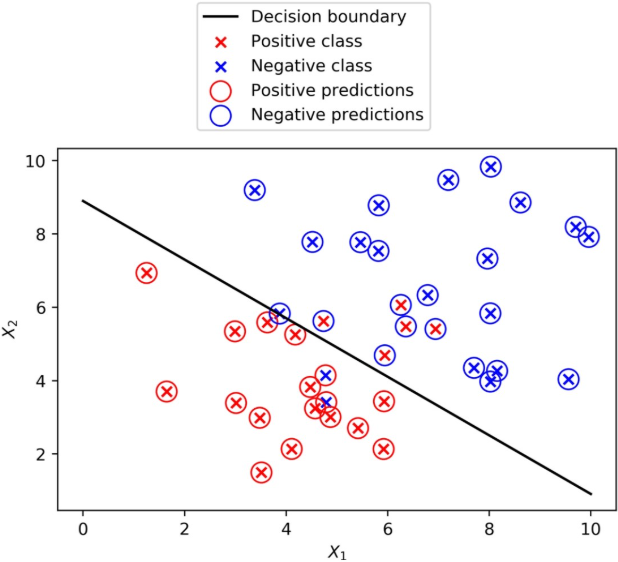

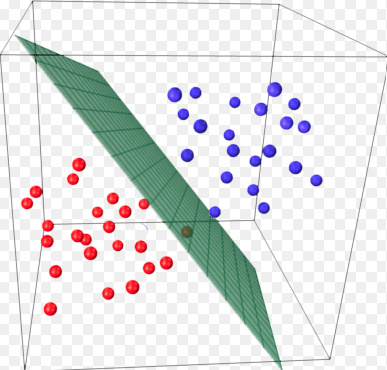

**1. The Math behind it:**
It starts like linear regression, computing a linear combination of the input features ($x$) and their corresponding weights ($w$), plus a bias term ($b$):

z (the logit function) that gives raw logits (or the risk score)

$$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

**2. The Sigmoid Function:**
Linear regression can output values from $-\infty$ to $+\infty$, but for classification, we need a probability between 0 and 1. We pass the linear output $z$ through the **sigmoid function** (also known as the logistic function):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The sigmoid function squashes any real-valued number into the range $[0, 1]$, producing an S-shaped curve. A common threshold is 0.5: if the output probability is $\ge 0.5$, the model predicts class 1 (Diabetes), otherwise class 0.

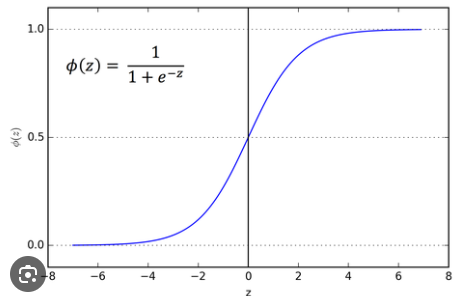

**Why use an Activation Function?**

The "Activation Function" (the Sigmoid) is the bridge between a math equation and a clinical decision.

* **The Problem:** The linear part of the model ($z = wx + b$) can produce any number. If you're predicting the probability of a heart attack, a result of **7.5** or **-2.0** is medically meaningless. 
* **The Solution:** The Sigmoid function acts as a **"Squashing Function."** It takes that infinite line and force-maps it into a strict range between $0$ and $1$. 
* **The Result:** Now, the output can be interpreted as a **probability** (e.g., "There is an 85% chance this patient has heart disease").

**3. The Log Loss Function (Cross-Entropy Loss):**
To evaluate how well the model predicts the target, it uses the **Log Loss** function. This loss function heavily penalizes confident but wrong predictions. The goal of the model is to minimize this loss.

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} [y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)})]$$

**4. Training with Gradient Descent:**

Training is the process of finding the best weights ($w$) and bias ($b$) that minimize the Log Loss. We use an iterative optimization called **Gradient Descent**:

1.  **Initialize:** Start with random weights (e.g., all zeros).
2.  **Predict:** Calculate the probability for all patients in the training set.
3.  **Calculate Gradient:** Find the derivative of the loss function with respect to each weight. This tells us which direction to "nudge" the weights to reduce the error.
4.  **Update:** Adjust the weights slightly:
    $$w = w - \alpha \cdot \frac{\partial J}{\partial w}$$
    *(Where $\alpha$ is the Learning Rate—essentially the "step size" of the update).*
5.  **Repeat:** Do this thousands of times until the loss stops decreasing.

---

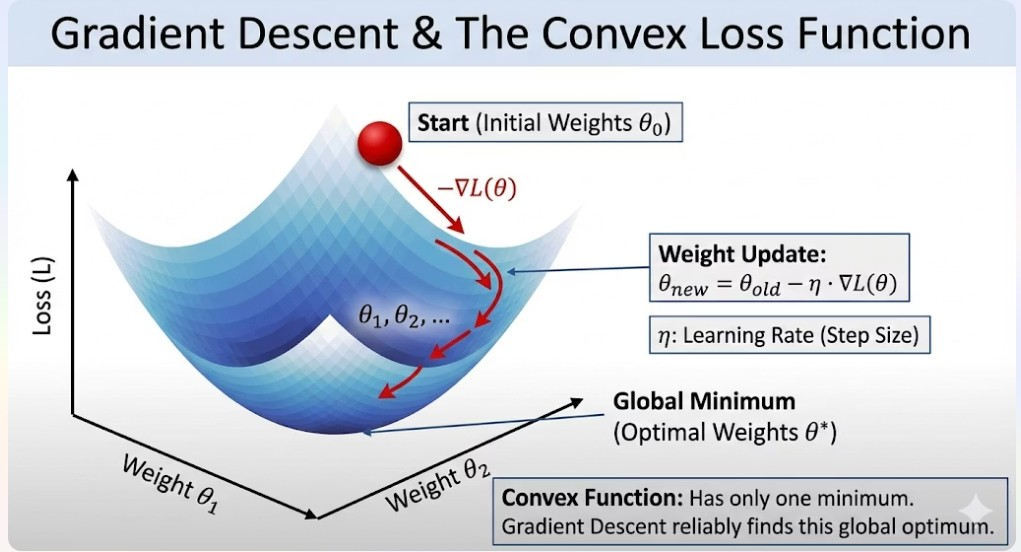

In [32]:
# Show the image convex_function.jpg
from IPython.display import Image
Image(filename='convex_function.jpg')

### Logistic regression as log-odds of an event occuring


#### Step 1: The Linear Recipe ($z$)
We start with the basic linear combination. Think of this as the **"Risk Score."** It's just a weighted sum of symptoms:
$$z = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$
At this stage, $z$ can be anything. If a patient is very healthy, $z$ might be $-50$. If they are very sick, $z$ might be $+100$.



#### Step 2: The Squashing (Sigmoid)
To turn that "Risk Score" into a **Probability ($P$)** between 0 and 1, we use the Sigmoid function:
$$P = \frac{1}{1 + e^{-z}}$$



#### Step 3: The Algebraic "U-Turn"
Now, let's work backward. We want to get $z$ (our straight line) all by itself on one side of the equation.

1.  **Multiply both sides** by $(1 + e^{-z})$:
    $$P(1 + e^{-z}) = 1$$

2.  **Distribute $P$**:
    $$P + Pe^{-z} = 1$$

3.  **Move $P$ to the other side**:
    $$Pe^{-z} = 1 - P$$

4.  **Divide by $P$**:
    $$e^{-z} = \frac{1 - P}{P}$$

5.  **Flip both sides** (take the reciprocal) to get rid of the negative sign in the exponent:
    $$e^z = \frac{P}{1 - P}$$

6.  **Take the Natural Log ($\ln$)** of both sides to "release" the $z$:
    $$\ln(e^z) = \ln\left(\frac{P}{1 - P}\right)$$
    $$z = \ln\left(\frac{P}{1 - P}\right)$$


#### Step 4: The Final Arrival
Since we defined $z$ at the very beginning as $w_0 + w_1x_1 + \dots$, we can just swap it back in:
$$\ln\left(\frac{P}{1 - P}\right) = w_0 + w_1x_1 + w_2x_2 + \dots$$

This left side—$\ln(\frac{P}{1 - P})$—is what we call the **Logit** or the **Log-Odds**.

---

#### Why does this matter for your Clinicians?

This is the language doctors actually speak in medical journals.

#### 1. What are "Odds"?
Odds are just the ratio of "Success" to "Failure."
* **Probability:** If 1 out of 5 people have a disease, $P = 1/5 = 0.20$ (20%).
* **Odds:** 1 person has it, 4 don't. Odds = $1:4$ or $0.25$.
* **Formula:** $Odds = \frac{P}{1 - P}$

#### 2. What is the "Odds Ratio" (OR)?
In your model, if the weight for "Smoking" ($w_1$) is $0.69$, how does a doctor interpret that?
* We take the exponent: $e^{0.69} \approx 2.0$.
* This means the **Odds Ratio** is 2.
* **Clinical Translation:** "A smoker is **twice as likely** (has 2x the odds) to have heart disease compared to a non-smoker, holding all other factors constant."

---

In [40]:
# get the model parameters in descending order and display them along with the feature names
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
print("Feature importance (sorted by absolute value of coefficients):")
print(feature_importance)


Feature importance (sorted by absolute value of coefficients):
                    Feature  Coefficient
1                   Glucose     1.169089
5                       BMI     0.682841
0               Pregnancies     0.376567
6  DiabetesPedigreeFunction     0.230001
7                       Age     0.149437
3             SkinThickness     0.026449
4                   Insulin    -0.032544
2             BloodPressure    -0.040237


---
## Model interpretation

### What is the "Odds Ratio" (OR)?
The **Odds Ratio** is simply a comparison of two different Odds.
$$\text{Odds Ratio} = \frac{\text{Odds of Group A}}{\text{Odds of Group B}}$$



#### 2. Why is it linked to the Weights?

This is the "Magic" of Logistic Regression. Let's look at our equation again:
$$\ln(\text{Odds}) = w_0 + w_1(\text{Smoking}) + w_2(\text{Age}) \dots$$

#### The Additive Scale (Log-Odds)
In the equation above, the weights are **additive**. 
* If you start smoking (Smoking goes from 0 to 1), you **add** $w_1$ to the total Log-Odds.
* But humans don't think in "Log-Odds." If I told a doctor "Your patient's log-odds of heart disease just increased by $0.69$," they would be confused.

#### The Multiplicative Scale (Odds Ratio)
To make it readable, we "un-log" the equation by taking the exponent ($e^x$) of both sides:
$$\text{Odds} = e^{(w_0 + w_1x_1 + \dots)}$$
$$\text{Odds} = e^{w_0} \cdot e^{w_1x_1} \cdot e^{w_2x_2} \dots$$

Notice what happened? The plus signs ($+$) became multiplication signs ($\cdot$). 
* When the feature $x_1$ (Smoking) increases by 1 unit, the total **Odds** are **multiplied** by $e^{w_1}$.
* Therefore, **$e^{w_1}$ IS the Odds Ratio.**

---

For this logistic regression model, each coefficient tells you how a one-unit increase in that feature changes the model’s estimated log-odds of diabetes.

Because you scaled the features before training, the “one unit” here means one standard deviation of the feature, not the raw measurement.

Interpretation rules:
- positive coefficient: higher feature value → higher predicted log-odds of diabetes
- negative coefficient: higher feature value → lower predicted log-odds of diabetes
- larger absolute value: stronger influence on the prediction

For your coefficients:

- `Glucose: 1.1691`
    - strongest positive effect
    - a 1-standard-deviation increase in glucose raises the log-odds of diabetes the most
- `BMI: 0.6828`
    - second strongest positive effect
    - higher BMI increases the predicted diabetes risk
- `DiabetesPedigreeFunction: 0.2300`
    - positive effect
    - a stronger family history score increases risk
- `Age: 0.1494`
    - positive effect
    - older age increases risk
- `Pregnancies: 0.3766`
    - positive effect
    - more pregnancies slightly increase predicted risk
- `SkinThickness: 0.0264`
    - small positive effect
    - a small increase in skin thickness slightly increases predicted risk
- `BloodPressure: -0.0402`
    - small negative effect
    - higher blood pressure slightly lowers the model’s predicted diabetes risk in this data
- `Insulin: -0.0325`
    - small negative effect
    - higher insulin values slightly lower the predicted risk in this model

A few important notes:
- These are associations learned by the model, not proof of causation.
- Because the features were standardized, the coefficients are roughly comparable in strength.
- The model uses these coefficients in the logistic formula:
    `logit(p) = intercept + sum(coef_i * feature_i)`
    and then converts `logit(p)` into a probability.

## 5. Model Evaluation

Now we'll check how well our model performs on the unseen test data.

In [34]:
y_pred = model.predict(X_test_scaled)

In [35]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.69


### 5.1. Confusion Matrix

A confusion matrix gives a more detailed breakdown of a model's performance. When we look at the plot generated below, we can read it in four quadrants:

- **Top-Left (True Negatives - TN):** The actual outcome was 'No Diabetes' and the model correctly predicted 'No Diabetes'.
- **Bottom-Right (True Positives - TP):** The actual outcome was 'Diabetes' and the model correctly predicted 'Diabetes'.
- **Top-Right (False Positives - FP):** The actual outcome was 'No Diabetes', but the model incorrectly predicted 'Diabetes' (Type I Error / False Alarm).
- **Bottom-Left (False Negatives - FN):** The actual outcome was 'Diabetes', but the model incorrectly predicted 'No Diabetes' (Type II Error / Missed Diagnosis). In healthcare, missing a diagnosis (FN) is often the most dangerous error.

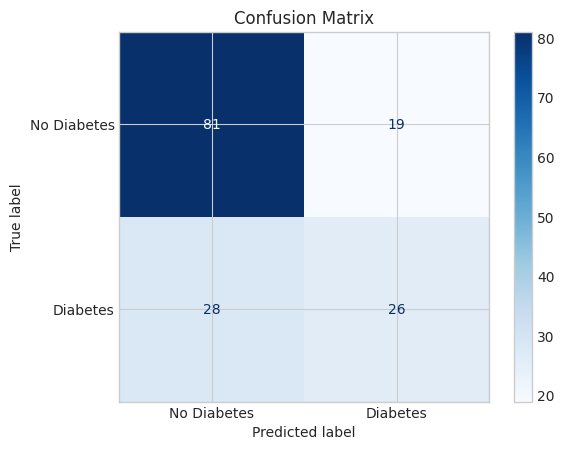

In [36]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

### 5.2. Classification Report

This report provides key metrics per class:
- **Precision:** Out of all the patients the model predicted would have diabetes, how many actually did? `TP / (TP + FP)`
- **TPR (True Positive Rate) or Recall or Sensitivity:** Out of all the patients who actually have diabetes, how many did the model correctly identify? `TP / (TP + FN)`
- **False Positive Rate (FPR)**: The ratio of incorrectly predicted positive observations to all actual negatives.
  
  $$
  \text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
  $$
- **Specificity**: Specificity measures the proportion of actual negative instances that are correctly identified by the model as negative. It represents the ability of the model to correctly identify negative instances

  $$
  \text{Specificity} = \frac{\text{TN}}{\text{TN} + \text{FP}} = 1 - \text{FPR}
  $$
- **F1-Score:** The harmonic mean of Precision and Recall. It provides a single metric to evaluate the model when you need to balance both. The formula is: `2 * (Precision * Recall) / (Precision + Recall)`.

In [37]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.74      0.81      0.78       100
    Diabetes       0.58      0.48      0.53        54

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.65       154
weighted avg       0.69      0.69      0.69       154



### **Better evaluation metrices for classification problems: ROC Curve and AUC (Area Under the Curve)**

Accuracy only tells us:

> “How many predictions were correct?”

But in healthcare, that’s not enough.

👉 What we really care about is:

> **Can the model correctly *rank* patients by risk?**

---

### 🎯 Think of It This Way

Imagine your model doesn’t just say:

* Diabetes / No Diabetes

Instead, it gives a **risk score**:

* Patient A → 0.9 (high risk)
* Patient B → 0.2 (low risk)

👉 The model is *ranking patients from most risky to least risky*

---

### 🔍 What ROC Curve Shows

The ROC curve answers this:

> “If we move the cutoff threshold, how well does the model separate sick vs healthy patients?”

* Lower threshold → catch more patients (but more false alarms)
* Higher threshold → fewer false alarms (but miss some patients)

👉 ROC shows this **trade-off across all possible thresholds**

- The **ROC curve** plots TPR (on the y-axis) against FPR (on the x-axis) for different classification thresholds. Each point on the curve represents a TPR/FPR pair corresponding to a particular threshold.

- The **AUC** is the area under this curve. AUC can range from 0 to 1:
  - **AUC = 1**: Perfect model, perfectly distinguishes between positive and negative classes.
  - **AUC = 0.5**: Model has no discrimination capability (equivalent to random guessing).
  - **AUC < 0.5**: Model is worse than random guessing (indicating it might be consistently predicting the opposite class).

---

### 📊 What AUC Really Means (This is the key insight)

> **AUC measures how good the model is at ranking patients correctly.**

More precisely:

> If you randomly pick:

* One patient with diabetes
* One patient without

👉 AUC = probability that the model gives a **higher risk score** to the diabetic patient

### 📈 How to Interpret AUC

* **0.5** → Random guessing (bad ranking)
* **0.7–0.8** → Decent ranking
* **0.8–0.9** → Strong model
* **1.0** → Perfect ranking

---

### ⚠️ Why This Matters in Healthcare

Even if the model isn’t perfect:

👉 If it ranks patients well:

* Doctors can focus on **high-risk patients first**
* Useful for **triage, screening, prioritization**

---

### 🧮 AUC Formula (Intuitive Version)

AUC = Number of correctly ranked pairs / Total possible pairs

---

### 🧠 Example

Suppose:

| Patient | True Label   | Score |
| ------- | ------------ | ----- |
| A       | Diabetic     | 0.9   |
| B       | Non-diabetic | 0.8   |
| C       | Diabetic     | 0.7   |
| D       | Non-diabetic | 0.3   |

Now compare all pairs:

* A vs B → correct ✅
* A vs D → correct ✅
* C vs B → wrong ❌
* C vs D → correct ✅

👉 3 correct out of 4

[
AUC = 0.75
]

---

AUC Score: 0.81


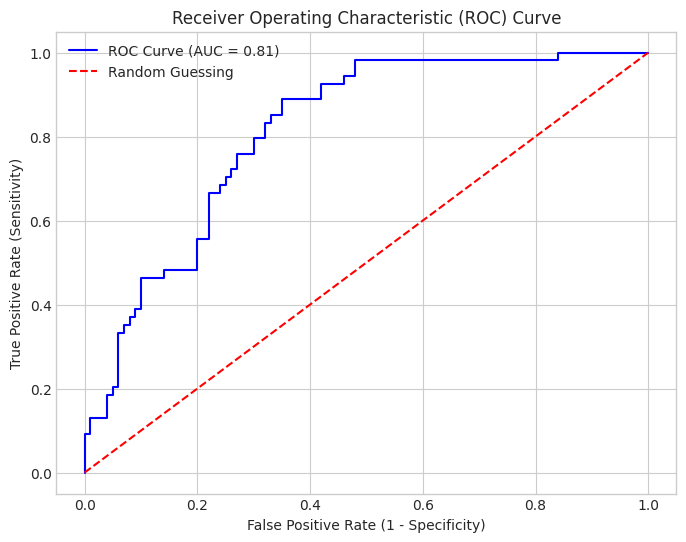

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the predicted probabilities for the 'Diabetes' class (class 1)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.2f}")

# Calculate points for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

### 5.4. The Challenge of Imbalanced Data

You might have noticed in our EDA (Exploratory Data Analysis) and Classification Report that there are roughly twice as many patients *without* diabetes as there are *with* diabetes (65% vs 35%). This is called **Imbalanced Data**.

**How it affects the model:** Machine learning algorithms learn by example. If they see a lot more of 'Class 0' (No Diabetes), they become very good at predicting 'Class 0', but might struggle to identify 'Class 1' (Diabetes). The model becomes biased toward the majority class.

**Techniques to handle imbalanced datasets (for future exploration):**
1.  **Oversampling:** Creating copies of the minority class so the model sees equal amounts of both.
2.  **Undersampling:** Randomly removing examples from the majority class to balance the data.
3.  **Synthetic Data Generation (SMOTE):** An algorithm that generates new, artificial examples of the minority class based on the existing ones.
4.  **Class Weights (Cost-Sensitive Learning):** Telling the model to apply a higher penalty (or "cost") when it makes a mistake on the minority class. In scikit-learn, this is often as simple as setting `class_weight='balanced'` when creating the model.

Understanding the imbalance is crucial because predicting a False Negative (missing a diabetes diagnosis) has a much higher real-world cost than a False Positive.

## 6. Making a Prediction on a New Patient

Let's see how to use our trained model to predict the outcome for a new, hypothetical patient.

In [39]:
# Data for a new patient
# Features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
new_patient_data = pd.DataFrame([{
    'Pregnancies': 2,
    'Glucose': 120,
    'BloodPressure': 70,
    'SkinThickness': 20,
    'Insulin': 79,
    'BMI': 25.0,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 33
}])

# IMPORTANT: Apply the same scaling to the new data
new_patient_scaled = scaler.transform(new_patient_data)

# Make the prediction
prediction = model.predict(new_patient_scaled)
prediction_proba = model.predict_proba(new_patient_scaled)

print(f"New Patient Data:\n{new_patient_data.to_string(index=False)}\n")

if prediction[0] == 1:
    print(f"Prediction: The model predicts that the patient HAS diabetes.")
else:
    print(f"Prediction: The model predicts that the patient does NOT have diabetes.")

print(f"Prediction Probability: [No Diabetes, Diabetes] = {prediction_proba[0]}")

New Patient Data:
 Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI  DiabetesPedigreeFunction  Age
           2      120             70             20       79 25.0                       0.5   33

Prediction: The model predicts that the patient does NOT have diabetes.
Prediction Probability: [No Diabetes, Diabetes] = [0.86645294 0.13354706]


## 7. Conclusion & Next Steps

Congratulations! You have successfully built and evaluated your first healthcare predictive model.

We have learned to:
1. Load and explore a real-world healthcare dataset.
2. Identify and handle missing data, a critical step in real projects.
3. Visualize data to gain insights, learned to identify outliers and handle them.
4. Prepare data for modeling using splitting and scaling.
5. Understand the core concepts of logistic regression and how to train a logistic regression model.
6. Evaluate the model using metrics beyond simple accuracy, like the confusion matrix, precision, and recall, auc, roc curve.
7. Use the trained model to make predictions on new data.
8. How to interpret the trained model.

**You can further explore:**
- Trying more complex models (e.g., Random Forest, Gradient Boosting).
- More advanced feature engineering.
- Techniques for handling imbalanced datasets more effectively.